In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/raw/1Money_20_04_2026.csv")

df["ДАТА"] = pd.to_datetime(df["ДАТА"], format="%d.%m.%Y", errors="coerce")
df = df[df["ДАТА"].notnull()].copy()

df["year"] = df["ДАТА"].dt.year
df["month"] = df["ДАТА"].dt.month
df["day_name"] = df["ДАТА"].dt.day_name()

expenses = df[df["ТИП"] == "Расход"].copy()

expenses.head(10)


In [ ]:
expenses["НА СЧЁТ / НА КАТЕГОРИЮ"].value_counts().head(30)

In [ ]:
category_map = {
    "Продукты (Продукты)": "Еда",
    "Хата": "Жильё",
    "Покупки (Техника)": "Техника",
    "ВелоШокс": "Велосипед",
    "Хата": "Жильё",
    "Развлечения": "Развлечения"
}

expenses["category_raw"] = expenses["НА СЧЁТ / НА КАТЕГОРИЮ"]
expenses["category_norm"] = expenses["category_raw"].map(category_map)
expenses[["category_raw", "category_norm"]].head(20)

In [ ]:
expenses["category_norm"] = expenses["category_norm"].fillna(expenses["category_raw"])

expenses[["category_raw", "category_norm"]].head(20)

In [ ]:
expenses["category_norm"].value_counts().head(30)

In [ ]:
category_sum = (
    expenses
    .groupby("category_norm")["СУММА"]
    .sum()
    .sort_values(ascending=False)
)

category_sum.head(20)


In [ ]:
import matplotlib.pyplot as plt
category_sum.head(15).plot(kind="bar", figsize=(12, 5))

plt.title("Expenses by normalized category")
plt.ylabel("Total Amount")
plt.show()

In [ ]:
required_categories = [
    "Жилье",
    "Еда",
    "Транспорт",
    "Здоровье",
    "Связь",
]

In [ ]:
expenses["is_required"] = expenses["category_norm"].isin(required_categories)

expenses[["category_norm", "is_required"]].head(20)

In [ ]:
expenses["expense_type"] = expenses["is_required"].map({
    True: "Обязательные",
    False: "Необязательные"
})
expenses[["category_norm", "expense_type"]].head(20)

In [ ]:
expense_type_sum = (
    expenses
    .groupby("expense_type")["СУММА"]
    .sum()
    .sort_values(ascending=False)
)

expense_type_sum

In [ ]:
expense_type_share = expense_type_sum / expense_type_sum.sum()
expense_type_share

In [ ]:
expense_type_share.plot(kind="bar", figsize=(8, 4))
plt.title("Required vs Optional expenses share")
plt.ylabel("Share")
plt.show()

In [ ]:
monthly_required = (
    expenses
    .groupby(["year", "month", "expense_type"])["СУММА"]
    .sum()
    .unstack()
    .fillna(0)
)

monthly_required

In [ ]:
monthly_required.plot(kind="bar", figsize=(12, 5))

plt.title("Required vs Optional expenses by month")
plt.ylabel("Total amount")
plt.show()

In [ ]:
df

In [7]:
# Task A
df = pd.read_csv("../data/raw/1Money_20_04_2026.csv")
df["ДАТА"] = pd.to_datetime(df["ДАТА"], format="%d.%m.%Y", errors="coerce")
df = df[df["ДАТА"].notnull()].copy()

df["year"] = df["ДАТА"].dt.year
df["month"] = df["ДАТА"].dt.month
df["day_name"] = df["ДАТА"].dt.day_name()

expenses = df[df["ТИП"] == "Расход"].copy()
expenses.head(10)


,ДАТА,ТИП,СО СЧЁТА,НА СЧЁТ / НА КАТЕГОРИЮ,СУММА,ВАЛЮТА,СУММА 2,ВАЛЮТА 2,МЕТКИ,ЗАМЕТКИ,year,month,day_name
4,2026-04-20,Расход,Карта,Продукты (Продукты),60.0,RUB,60.0,RUB,NaN,NaN,2026,4,Monday
5,2026-04-20,Расход,Карта,Кафе (Кофейня),300.0,RUB,300.0,RUB,NaN,NaN,2026,4,Monday
7,2026-04-19,Расход,Карта,Кафе (Кофейня),270.0,RUB,270.0,RUB,NaN,NaN,2026,4,Sunday
8,2026-04-19,Расход,Карта,Продукты (Продукты),810.0,RUB,810.0,RUB,NaN,NaN,2026,4,Sunday
9,2026-04-19,Расход,Карта,ВелоШокс,2290.0,RUB,2290.0,RUB,NaN,Флягодержатели и титановые болты,2026,4,Sunday
11,2026-04-19,Расход,Карта,ВелоШокс,1570.0,RUB,1570.0,RUB,NaN,Замок цепи и переходник,2026,4,Sunday
12,2026-04-18,Расход,Карта,ВелоШокс,2660.0,RUB,2660.0,RUB,NaN,Мультитул,2026,4,Saturday
14,2026-04-18,Расход,Карта,Кафе (Кофейня),270.0,RUB,270.0,RUB,NaN,NaN,2026,4,Saturday
15,2026-04-18,Расход,Карта,Кафе (Кофейня),300.0,RUB,300.0,RUB,NaN,NaN,2026,4,Saturday
16,2026-04-18,Расход,Карта,ВелоШокс,5550.0,RUB,5550.0,RUB,NaN,Напольный насос,2026,4,Saturday


In [8]:
# Task B
expenses["НА СЧЁТ / НА КАТЕГОРИЮ"].value_counts().head(30)

НА СЧЁТ / НА КАТЕГОРИЮ
Продукты (Продукты)     451
Кафе (Кофейня)          352
Кафе (Еда)              169
Продукты                 62
Покупки (Разное)         54
ВелоШокс                 48
Покупки                  47
Продукты (Вода)          42
Здоровье (Препараты)     37
Здоровье (Услуги)        33
Хата                     31
Покупки (Подписки)       31
Мем                      30
Интернет                 29
Покупки (Услуги)         27
Транспорт (Такси)        26
Покупки (Техника)        24
Развлечения              23
Покупки (Для дома )      21
Покупки (Подарки)        17
Покупки (Косметикс )     14
Кафе                     13
Покупки (Одежда)         13
Транспорт (Автобусы)     10
Продукты (Кофе)           7
Транспорт (Метро)         7
Спорт (Абонемент )        7
Транспорт (Жд )           6
Транспорт                 3
Кафе (Прочее)             3
Name: count, dtype: int64

In [9]:
# Task C
category_map = {
    "Продукты (Продукты)": "Продукты",
    "Продукты": "Продукты",
    "Продукты (Вода)": "Продукты",
    "Продукты (Кофе)": "Продукты",
    "Кафе (Кофейня)": "Кафе",
    "Кафе (Еда)": "Кафе",
    "Кафе (Прочее)": "Кафе",
    "Покупки (Разное)": "Покупки",
    "Покупки": "Покупки",
    "Покупки (Подписки)": "Покупки",
    "Покупки (Сервер)": "Покупки",
    "Покупки (Услуги)": "Покупки",
    "Покупки (Техника)": "Покупки",
    "Покупки (Для дома )": "Покупки",
    "Покупки (Игры)": "Покупки",
    "Покупки (Подарки)": "Покупки",
    "Покупки (Косметикс )": "Покупки",
    "Покупки (Одежда)": "Покупки",
    "ВелоШокс": "Вело-покупки",
    "Здоровье (Препараты)": "Здоровье",
    "Здоровье (Услуги)": "Здоровье",
    "Хата": "Жилье",
    "Мем": "Перевод маме",
    "Интернет": "Интернет",
    "Транспорт (Такси)": "Транспорт",
    "Транспорт (Самолет)": "Транспорт",
    "Транспорт (Автобусы)": "Транспорт",
    "Транспорт (Метро)": "Транспорт",
    "Транспорт (Жд )": "Транспорт",
    "Транспорт": "Транспорт",
    "Развлечения": "Развлечения",
    "Спорт (Абонемент )": "Спорт зал",
    "Спорт (Бады)": "Спорт зал",
    "Спорт (Тренер)": "Спорт зал",
    "Спорт (Напитки)": "Спорт зал",
    "Спорт": "Спорт зал",
}

expenses["category_raw"] = expenses["НА СЧЁТ / НА КАТЕГОРИЮ"]
expenses["category_norm"] = expenses["category_raw"].map(category_map)
expenses["category_norm"]  = expenses["category_norm"].fillna(expenses["category_raw"])  # данная строка не нужна, так-как я уже проверил все поля
# expenses["category_norm"].isna().sum() # Проверка 1
# expenses[["category_raw", "category_norm"]].isna().value_counts() # Проверка 2
expenses[["category_raw", "category_norm"]].head(20)

,category_raw,category_norm
4,Продукты (Продукты),Продукты
5,Кафе (Кофейня),Кафе
7,Кафе (Кофейня),Кафе
8,Продукты (Продукты),Продукты
9,ВелоШокс,Вело-покупки
11,ВелоШокс,Вело-покупки
12,ВелоШокс,Вело-покупки
14,Кафе (Кофейня),Кафе
15,Кафе (Кофейня),Кафе
16,ВелоШокс,Вело-покупки


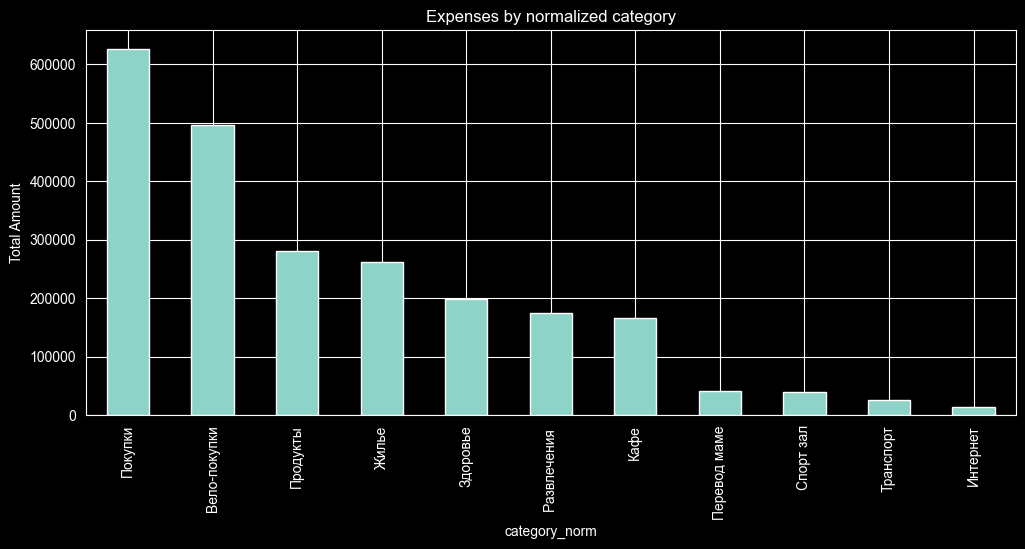

In [10]:
# Task D
sum_expenses_category_norm = (
    expenses
    .groupby("category_norm")["СУММА"]
    .sum()
    .sort_values(ascending=False)
)
sum_expenses_category_norm.head(15).plot(kind="bar", figsize=(12, 5))
plt.title("Expenses by normalized category")
plt.ylabel("Total Amount")
plt.show()



In [12]:
# Task E
required_categories = [
    "Жилье",
    "Продукты",
    "Здоровье",
    "Интернет",
    "Спорт зал",
]

expenses["is_required"] = expenses["category_norm"].isin(required_categories)
expenses["expense_type"] = expenses["is_required"].map({
    True: "Обязательные",
    False: "Необязательные"
})
expenses[["category_norm", "expense_type"]].head(20)

,category_norm,expense_type
4,Продукты,Обязательные
5,Кафе,Необязательные
7,Кафе,Необязательные
8,Продукты,Обязательные
9,Вело-покупки,Необязательные
11,Вело-покупки,Необязательные
12,Вело-покупки,Необязательные
14,Кафе,Необязательные
15,Кафе,Необязательные
16,Вело-покупки,Необязательные


In [13]:
# Task F
required_categories_sum = (
    expenses
    .groupby("expense_type")["СУММА"]
    .sum()
    .sort_values(ascending=False)
)
required_categories_sum

required_categories_share = required_categories_sum / required_categories_sum.sum()
required_categories_share

expense_type
Необязательные    0.658173
Обязательные      0.341827
Name: СУММА, dtype: float64

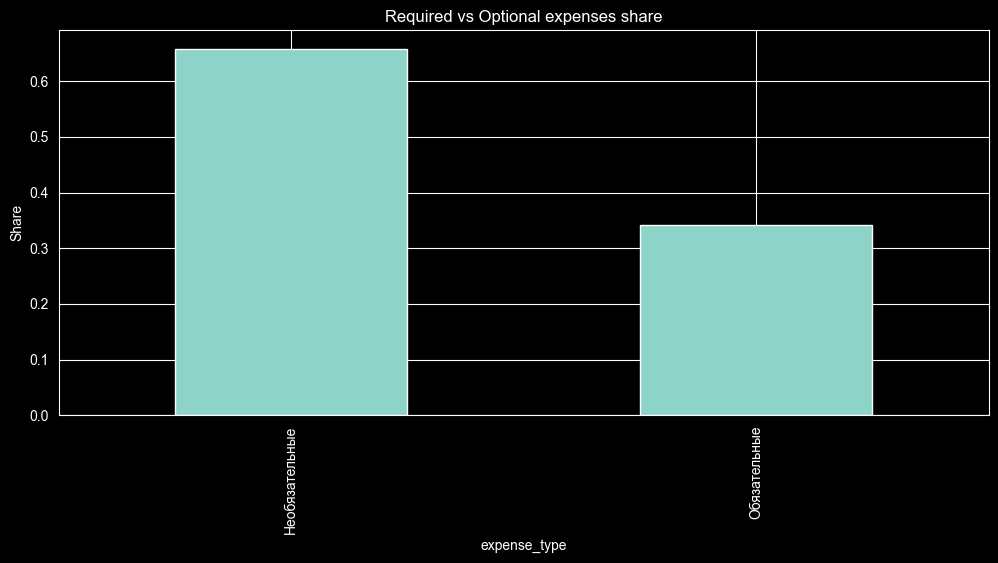

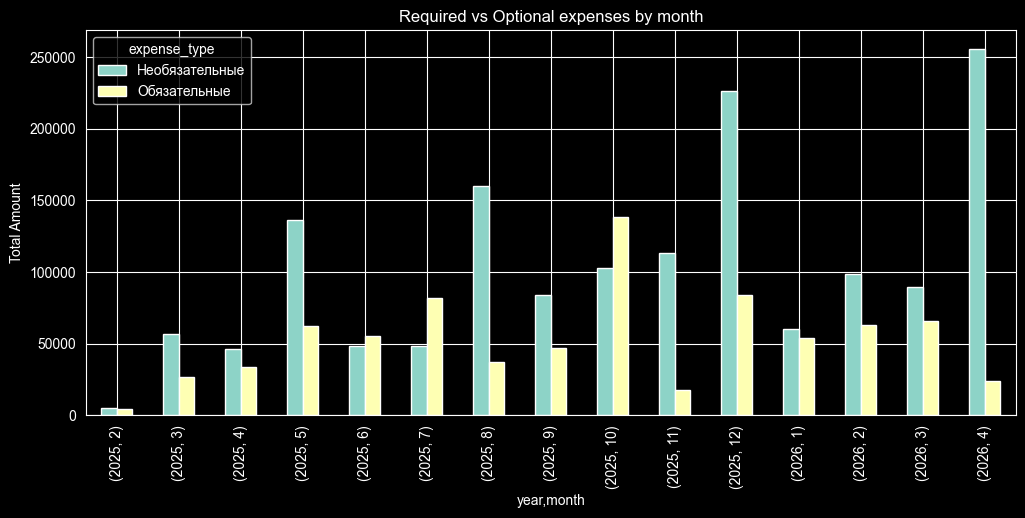

In [14]:
# Task G
required_categories_share.plot(kind="bar", figsize=(12, 5))
plt.title("Required vs Optional expenses share")
plt.ylabel("Share")
plt.show()

required_categories_monthly = (
    expenses
    .groupby(["year", "month", "expense_type"])["СУММА"]
    .sum()
    .unstack()
    .fillna(0)
)
required_categories_monthly.plot(kind="bar", figsize=(12, 5))
plt.title("Required vs Optional expenses by month")
plt.ylabel("Total Amount")
plt.show()

## Выводы

- Сырые категории расходов были нормализованы в более крупные и понятные группы.
- Исходные категории сохранены в `category_raw`, чтобы не терять первичные данные.
- Разделение на обязательные и необязательные расходы является субъективным, но полезным для оценки гибкости бюджета.
- Обязательные расходы показывают минимальную базовую нагрузку на бюджет.
- Необязательные расходы сильнее отражают стиль потребления, хобби и разовые покупки.
- Анализ по месяцам показывает, в какие периоды необязательные расходы особенно сильно увеличивали общий расход.
- В дальнейшем можно улучшить проект: вынести `category_map` и список обязательных категорий в отдельный config-файл.
- В апреле 2026 заметен сильный рост необязательных расходов, связанный с крупными велопокупками.
- Это показывает, что разовые хобби-покупки могут сильно искажать месячный бюджет и требуют отдельного учёта.